# IPCS Forward Solver (clean wrapper)
This Notebook manages the parameters for `ipcs_runner.py`.


In [82]:
import sys
from pathlib import Path

ROOT = Path('/app')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from airflow_estimation.forward_navier_stokes.ipcs_runner import (
    IPCSConfig,
    run_ipcs,
    plot_streamlines,
    plot_glyphs,
    write_adios_checkpoint,
    write_vtx,
)


In [83]:
cfg = IPCSConfig(
    meshfile=Path('/app/exp_sample_based_estimation/exp_wind_comparison/refined.msh'),
    T=3.0,
    dt=1.0/2000.0,
    mu=1e-4,
    rho=1.0,
    inflow_name='Inlet',
    outflow_name='Outlet',
    wall_names=('Walls',),
    t_ramp_up=2.0,
    v_max=1.0,
    tol_stationary=1e-6,
    enable_supg=True,
    supg_scale=1.0,
)

result = run_ipcs(cfg)
print('Boundary names:', result.name_to_id)
print('Iterations:', len(result.l2_errors))
print('Converged iteration:', result.converged_iteration)
print('Final L2 delta(u):', result.l2_errors[-1] if result.l2_errors else None)


Info    : Reading '/app/exp_sample_based_estimation/exp_wind_comparison/refined.msh'...
Info    : 25 entities
Info    : 6945 nodes
Info    : 13890 elements
Info    : Done reading '/app/exp_sample_based_estimation/exp_wind_comparison/refined.msh'
Info    : Reading '/app/exp_sample_based_estimation/exp_wind_comparison/refined.msh'...
Info    : 25 entities
Info    : 6945 nodes
Info    : 13890 elements
Info    : Done reading '/app/exp_sample_based_estimation/exp_wind_comparison/refined.msh'
Boundary names: {'Inlet': 13, 'Outlet': 14, 'Walls': 15, 'inner_surface': 16}
Iterations: 4001
Converged iteration: 4000
Final L2 delta(u): 5.869679276232902e-09


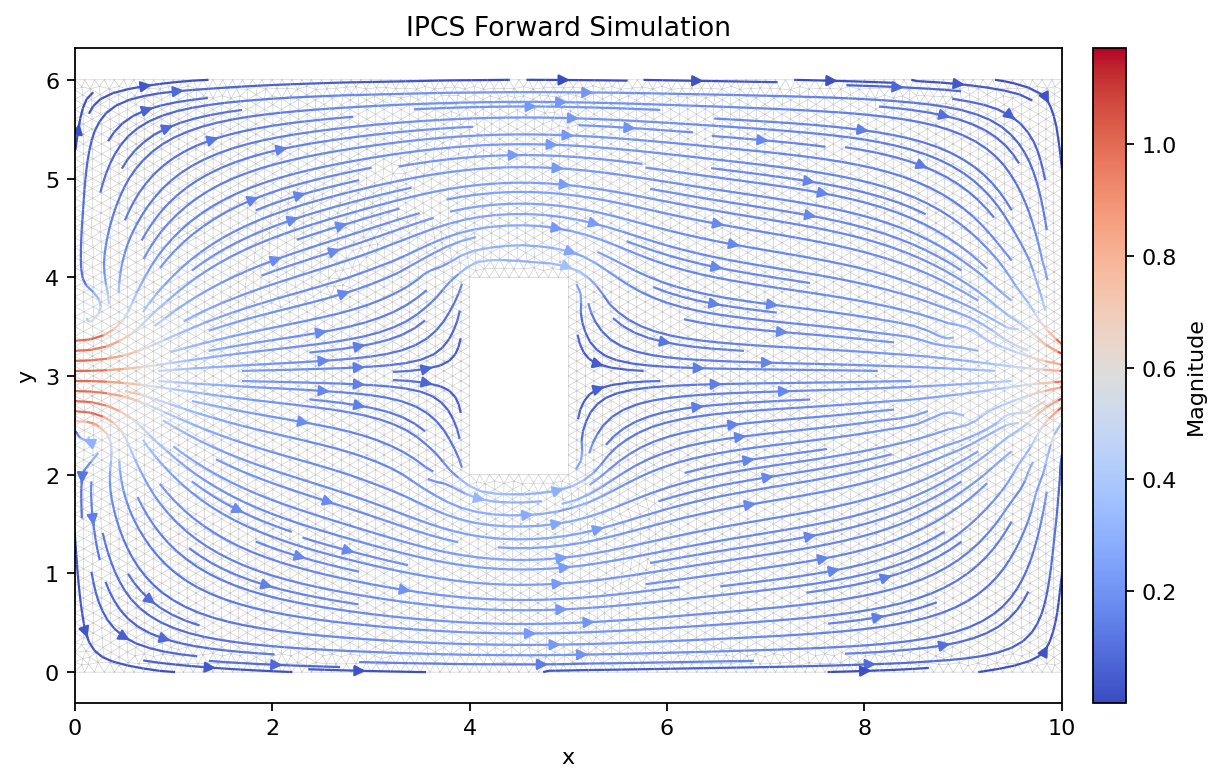

In [86]:
plot_streamlines(result, nx=100, ny=50, density=2)
# plot_glyphs(result)


In [85]:
# Solver checkpoint for DOLFINx/adios4dolfinx
write_adios_checkpoint(
    Path('/app/exp_sample_based_estimation/exp_wind_comparison/airflow_ipcs.bp'),
    result,
    function_name='velocity_H2',
)

# ParaView-friendly output
write_vtx(
    Path('/app/exp_sample_based_estimation/exp_wind_comparison/airflow_ipcs_vtx.bp'),
    result,
    t=0.0,
)
